# DPN

In [30]:
import os
from datetime import datetime

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

from tqdm import tqdm
from pprint import pprint

import warnings
warnings.filterwarnings('ignore')
np.set_printoptions(precision=3)      # decimal places for outputs from numpy
pd.set_option("display.precision", 3) # decimal places for outputs from pandas 
pd.options.display.max_rows=15        # max rows for outputs from pandas

In [31]:
from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.svm import SVC
from sklearn.svm import LinearSVC

from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, fbeta_score, matthews_corrcoef
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, multilabel_confusion_matrix

from sklearn.metrics import make_scorer
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import ParameterGrid

In [32]:
%load_ext autoreload
%autoreload 2
from dataload import DAN_data
#import vmodels

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Functions

### multiclass_metrics

In [33]:
def multiclass_metrics(confusion_matrix, labels="", result_aggregation='by_statistics', verbosity=1):
    """ result_aggregation: 'by_statistics' or 'by_class' - how results are aggregated
        verbosity         : level of details in printing results            
    """
    n_classes = confusion_matrix.shape[0]

    if not labels: 
        labels = list(range(n_classes-1))
   
    recall_list = []
    specificity_list = []
    youden_index_list = []
    support_list = []

    total = np.sum(confusion_matrix)

    for c in range(n_classes):
        TP = confusion_matrix[c, c]
        FN = np.sum(confusion_matrix[c, :]) - TP # Predicted not Class c, Actual Class c
        FP = np.sum(confusion_matrix[:, c]) - TP # Predicted Class c, Actual not Class c
        TN = total - TP - FP - FN 
        support = np.sum(confusion_matrix[c, :])  # Total actual instances of class c

        recall = TP / (TP + FN) if (TP + FN) > 0 else 0
        specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
        youden_index = recall + specificity - 1
        

        recall_list.append(recall)
        specificity_list.append(specificity)
        youden_index_list.append(youden_index)        

        support_list.append(support)

        if verbosity > 1:
            print(f"Class {labels[c]}:")
            print(f"  TP = {TP}, FN = {FN}, FP = {FP}, TN = {TN}, Support = {support}")
            print(f"  Sensitivity = {recall:.3f}") # sensitivity is the same as recall
            print(f"  Specificity = {specificity:.3f}")
            print(f"  Youden Index = {youden_index:.3f}")
            print("")

    # Convert to numpy arrays for aggregation
    support_array = np.array(support_list)
    weights = support_array / np.sum(support_array)

    # Macro averages (equal weight)
    macro_recall = np.mean(recall_list)
    macro_specificity = np.mean(specificity_list)
    macro_youden = np.mean(youden_index_list)

    # Weighted averages
    weighted_recall = np.average(recall_list, weights=weights)
    weighted_specificity = np.average(specificity_list, weights=weights)
    weighted_youden = np.average(youden_index_list, weights=weights)

    # compute accuracy
    correct = np.trace(confusion_matrix)  
    accuracy = correct / total        

    if verbosity > 0:
        print(f"  Accuracy = {accuracy:.3f}")

        print("Macro-Averaged Metrics:")
        print(f"  Sensitivity (Macro) = {macro_recall:.3f}")
        print(f"  Specificity (Macro) = {macro_specificity:.3f}")
        print(f"  Youden Index (Macro) = {macro_youden:.3f}")
        print("")
        print("Weighted-Averaged Metrics:")
        print(f"  Sensitivity (Weighted) = {weighted_recall:.3f}")
        print(f"  Specificity (Weighted) = {weighted_specificity:.3f}")
        print(f"  Youden Index (Weighted) = {weighted_youden:.3f}")
        print("")

    if result_aggregation == 'by_statistics':
        result = {
            "per_class": {
                "sensitivity": recall_list,
                "specificity": specificity_list,
                "youden_index": youden_index_list,
                "support": support_list,
            },
            "macro_avg": {                
                "sensitivity": macro_recall,
                "specificity": macro_specificity,
                "youden_index": macro_youden,
                "accuracy": accuracy,
            },
            "weighted_avg": {
                "sensitivity": weighted_recall,
                "specificity": weighted_specificity,
                "youden_index": weighted_youden,
            }
        }
    else: # 'by_class'
        result = {
            labels[i] : {
                "support": support_list[i],
                "sensitivity": [recall_list[i], macro_recall[i], weighted_recall[i]],
                "specificity": [specificity_list[i], macro_specificity[i], weighted_specificity[i]],
                "youden_index": [youden_index_list[i], macro_youden[i], weighted_youden[i]],
            }
            for i in labels
        }    
    return result


### Binary Classification Metrics

In [34]:
def binary_classification_metrics(confusion_matrix, labels="", verbosity=1):
    """ verbosity : level of details in printing results            
    """
    tn, fp, fn, tp = confusion_matrix.ravel()

    accuracy = (tp+tn)/(tp+tn+fp+fn)
    precision = tp/(tp+fp)
    recall = tp/(tp+fn) # sensitivity; accuracy in predicting true positives
    specificity = tn / (tn + fp) # accuracy in predicting true negatives
    youden = recall + specificity - 1

    tpr = fp / (fp+tn)
    plr = recall/tpr   

    f1 = 2 *(precision*recall)/(precision+recall)
   
    if verbosity > 0:
        print(f"sensitivity/recall: {recall:.3f}")
        print(f"specificity: {specificity:.3f}")
        print(f"youden_index: {youden:.3f}")
        print(f"accuracy: {accuracy:.3f}")
        print(f"precision: {precision:.3f}")
        print(f"f1: {f1:.3f}")
        print("")
    if verbosity > 1:
        print(f"tpr: {tpr:.3f}")
        print(f"plr: {plr:.3f}")
        print("---")
        if labels: print(labels)
        print(f"TN {tn}   FP {fp}")
        print(f"FN {fn}   TP {tp}")        
        print(confusion_matrix)
        print("")

    scores = {
        "sensitivity": recall,
        "specificity": specificity,
        "youden_index": youden,
        "accuracy": accuracy,
        "precision": precision,
        "f1": f1,
        "tpr": tpr,
        "plr": plr,
    }

    return scores

### Data Loading

In [35]:
D = DAN_data("SudoscanRaw.xlsx")
D.load()
D.df.tail(3)

,CODE,AGE,DM_DUR,HBA1C,MNSI,SSA_L,SSC_L,SPSA_L,SPSC_L,MCV_L,...,HPN_Y,PAOD_Y,DSLPDMIA_Y,CKD_Y,GBS_Y,DEC_VS_Y,DEC_PPS_Y,DEC_LTS_Y,DEC_AR_Y,Negative
184,188,36,1.0,6.18,3,11.45,49.2,13.79,40.2,41.8,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0
185,189,60,5.0,12.20,8,5.03,37.9,0.00,0.0,36.3,...,1.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0
186,190,65,15.0,7.59,8,0.00,0.0,0.00,0.0,43.2,...,1.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,0


In [36]:
df = D.df
data_cols = list(set(df.columns) - set(D.non_data_cols))
print(len(data_cols), data_cols)

40 ['DEC_PPS_Y', 'MNSI', 'CMAPANK_R', 'SPSA_L', 'DSLPDMIA_Y', 'DEC_AR_Y', 'FWAVE_L', 'HBA1C', 'SSC_L', 'SSC_R', 'SUBJ_Y', 'MCV_R', 'INSULIN_Y', 'AGE', 'CMAPKNE_L', 'CKD_Y', 'MCV_L', 'DEC_VS_Y', 'SPSA_R', 'SPSC_L', 'NS', 'HPN_Y', 'FWAVE_R', 'GBS_Y', 'SSA_R', 'DL_L', 'HAND_PCT_ASYM', 'SEX_M', 'CAS', 'FEET_PCT_ASYM', 'CMAPANK_L', 'DM_DUR', 'DL_R', 'HAND_MEAN_ESC', 'PAOD_Y', 'DEC_LTS_Y', 'FEET_MEAN_ESC', 'SSA_L', 'SPSC_R', 'CMAPKNE_R']


In [37]:
df.columns

Index(['CODE', 'AGE', 'DM_DUR', 'HBA1C', 'MNSI', 'SSA_L', 'SSC_L', 'SPSA_L',
       'SPSC_L', 'MCV_L', 'DL_L', 'CMAPANK_L', 'CMAPKNE_L', 'FWAVE_L', 'SSA_R',
       'SSC_R', 'SPSA_R', 'SPSC_R', 'MCV_R', 'DL_R', 'CMAPANK_R', 'CMAPKNE_R',
       'FWAVE_R', 'FEET_MEAN_ESC', 'FEET_PCT_ASYM', 'HAND_MEAN_ESC',
       'HAND_PCT_ASYM', 'NS', 'CAS', 'Confirmed', 'Probable', 'Possible',
       'Any_DPN', 'SEX_M', 'SUBJ_Y', 'INSULIN_Y', 'HPN_Y', 'PAOD_Y',
       'DSLPDMIA_Y', 'CKD_Y', 'GBS_Y', 'DEC_VS_Y', 'DEC_PPS_Y', 'DEC_LTS_Y',
       'DEC_AR_Y', 'Negative'],
      dtype='object')

In [38]:
# check codes of patients that were dropped
set (range(1, 191)) - set(D.df.CODE.values) 

{36, 46, 173}

## Multi-Class Study
('Negative', 'Possible', 'Probable', 'Confirmed')

### Data Inspection

In [39]:
D.multi_classes

['Negative', 'Possible', 'Probable', 'Confirmed']

In [40]:
X = df[data_cols]
y = df[D.multi_classes]
X.shape, y.shape

((187, 40), (187, 4))

In [41]:
y

,Negative,Possible,Probable,Confirmed
0,0,0,0,1
1,0,1,0,0
2,0,0,0,1
3,0,0,0,1
4,0,0,0,1
...,...,...,...,...
182,0,0,1,0
183,0,1,0,0
184,0,0,1,0
185,0,0,0,1


In [42]:
# get supports for each class
y.sum()

Negative       8
Possible      22
Probable      27
Confirmed    130
dtype: int64

### Train Test Split

In [43]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.25, random_state=0, stratify=y)
print(X_train.shape, X_val.shape, y_train.shape, y_val.shape)
y_val

(140, 40) (47, 40) (140, 4) (47, 4)


,Negative,Possible,Probable,Confirmed
27,0,0,0,1
110,0,0,0,1
50,0,0,0,1
83,0,0,0,1
91,0,1,0,0
...,...,...,...,...
161,0,0,0,1
95,0,0,0,1
29,0,1,0,0
162,0,0,0,1


### Dummy Classifier

In [44]:

clf = DummyClassifier(strategy="most_frequent").fit(X_val, y_val) 
y_pred = clf.predict(X_val)

In [45]:
cm = confusion_matrix(
    np.argmax(y_val, axis=1), # convert 2D predictions to 1D
    np.argmax(y_pred, axis=1) # convert 2D predictions to 1D
)
cm

array([[ 0,  0,  0,  2],
       [ 0,  0,  0,  5],
       [ 0,  0,  0,  7],
       [ 0,  0,  0, 33]], dtype=int64)

In [46]:
r = multiclass_metrics(cm, labels=D.multi_classes, result_aggregation='by_statistics', verbosity=2)
pprint(r)

Class Negative:
  TP = 0, FN = 2, FP = 0, TN = 45, Support = 2
  Sensitivity = 0.000
  Specificity = 1.000
  Youden Index = 0.000

Class Possible:
  TP = 0, FN = 5, FP = 0, TN = 42, Support = 5
  Sensitivity = 0.000
  Specificity = 1.000
  Youden Index = 0.000

Class Probable:
  TP = 0, FN = 7, FP = 0, TN = 40, Support = 7
  Sensitivity = 0.000
  Specificity = 1.000
  Youden Index = 0.000

Class Confirmed:
  TP = 33, FN = 0, FP = 14, TN = 0, Support = 33
  Sensitivity = 1.000
  Specificity = 0.000
  Youden Index = 0.000

  Accuracy = 0.702
Macro-Averaged Metrics:
  Sensitivity (Macro) = 0.250
  Specificity (Macro) = 0.750
  Youden Index (Macro) = 0.000

Weighted-Averaged Metrics:
  Sensitivity (Weighted) = 0.702
  Specificity (Weighted) = 0.298
  Youden Index (Weighted) = 0.000

{'macro_avg': {'accuracy': 0.7021276595744681,
               'sensitivity': 0.25,
               'specificity': 0.75,
               'youden_index': 0.0},
 'per_class': {'sensitivity': [0.0, 0.0, 0.0, 1.0],
  

### Random Forest

In [47]:
clf = RandomForestClassifier(max_features = 4, random_state = 0).fit(X_train, y_train)
y_pred = clf.predict(X_val)

In [48]:
pprint(
    multiclass_metrics(
        confusion_matrix(
            np.argmax(y_val, axis=1), 
            np.argmax(y_pred, axis=1) 
        ), 
        labels=D.multi_classes, result_aggregation='by_statistics', verbosity=2)
)

Class Negative:
  TP = 1, FN = 1, FP = 7, TN = 38, Support = 2
  Sensitivity = 0.500
  Specificity = 0.844
  Youden Index = 0.344

Class Possible:
  TP = 2, FN = 3, FP = 1, TN = 41, Support = 5
  Sensitivity = 0.400
  Specificity = 0.976
  Youden Index = 0.376

Class Probable:
  TP = 1, FN = 6, FP = 1, TN = 39, Support = 7
  Sensitivity = 0.143
  Specificity = 0.975
  Youden Index = 0.118

Class Confirmed:
  TP = 32, FN = 1, FP = 2, TN = 12, Support = 33
  Sensitivity = 0.970
  Specificity = 0.857
  Youden Index = 0.827

  Accuracy = 0.766
Macro-Averaged Metrics:
  Sensitivity (Macro) = 0.503
  Specificity (Macro) = 0.913
  Youden Index (Macro) = 0.416

Weighted-Averaged Metrics:
  Sensitivity (Weighted) = 0.766
  Specificity (Weighted) = 0.887
  Youden Index (Weighted) = 0.653

{'macro_avg': {'accuracy': 0.7659574468085106,
               'sensitivity': 0.5031385281385281,
               'specificity': 0.9131944444444444,
               'youden_index': 0.41633297258297264},
 'per_clas

### Decision Tree

In [49]:
clf = DecisionTreeClassifier(max_depth = 4, min_samples_leaf = 8, random_state = 0).fit(X_train, y_train)
y_pred = clf.predict(X_val)
pprint(
    multiclass_metrics(
        confusion_matrix(
            np.argmax(y_val, axis=1), 
            np.argmax(y_pred, axis=1) 
        ), 
        labels=D.multi_classes, result_aggregation='by_statistics', verbosity=2)
)

Class Negative:
  TP = 1, FN = 1, FP = 6, TN = 39, Support = 2
  Sensitivity = 0.500
  Specificity = 0.867
  Youden Index = 0.367

Class Possible:
  TP = 1, FN = 4, FP = 1, TN = 41, Support = 5
  Sensitivity = 0.200
  Specificity = 0.976
  Youden Index = 0.176

Class Probable:
  TP = 3, FN = 4, FP = 1, TN = 39, Support = 7
  Sensitivity = 0.429
  Specificity = 0.975
  Youden Index = 0.404

Class Confirmed:
  TP = 33, FN = 0, FP = 1, TN = 13, Support = 33
  Sensitivity = 1.000
  Specificity = 0.929
  Youden Index = 0.929

  Accuracy = 0.809
Macro-Averaged Metrics:
  Sensitivity (Macro) = 0.532
  Specificity (Macro) = 0.937
  Youden Index (Macro) = 0.469

Weighted-Averaged Metrics:
  Sensitivity (Weighted) = 0.809
  Specificity (Weighted) = 0.938
  Youden Index (Weighted) = 0.746

{'macro_avg': {'accuracy': 0.8085106382978723,
               'sensitivity': 0.5321428571428571,
               'specificity': 0.936607142857143,
               'youden_index': 0.46875},
 'per_class': {'sensiti

### Grid Search Optimization

#### grid_search_nocv

In [50]:
def grid_search_nocv(estimator, param_grid, X, y, test_size,                      
                     random_state, verbosity, labels="", multiclass=True, 
                     scoring='youden_index', score_aggregation='weighted_avg'):
    
    def get_score(metrics):
        # metrics is the return value of multiclass_metrics(), which is a dictionary of dictionaries
        assert scoring in ['sensitivity', '', 'specificity', 'youden_index', 'accuracy'], f'Invalid scoring parameter  {scoring}'
        assert score_aggregation in ['per_class', 'macro_avg', 'weighted_avg'], f'Invalid score aggregation parameter {score_aggregation}'
        if scoring=='accuracy':
            assert score_aggregation=='macro_avg', f'Score aggregation should be macro_avg for accuracy '
        return metrics[score_aggregation][scoring] 

    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=test_size, random_state=random_state)    
    best_score = 0
    best_grid = None
    best_scores = []
    best_grids = []
    for g in tqdm(ParameterGrid(param_grid)):
        estimator.set_params(**g)
        try:
            estimator.fit(X_train,y_train)
            y_pred = estimator.predict(X_val)

            if multiclass:
                y_pred = np.argmax(y_pred, axis=1)
                y_val = np.argmax(y_val, axis=1)                

            cm = confusion_matrix(y_val, y_pred)            
            metrics = multiclass_metrics(cm, labels=labels, result_aggregation='by_statistics', verbosity=0)
            pprint(metrics)
            score = get_score(metrics)
            

            if verbosity>1:
                print(score, end=" ")
            if score > best_score: # save if best
                best_score = score
                best_grid = g                
                best_scores.append(best_score)
                best_grids.append(best_grid)
                if verbosity>1:
                    print("\n", best_score, best_grid, "\n")
        except:
            continue
    return best_scores, best_grids

In [51]:
estimator= RandomForestClassifier()
model_class = RandomForestClassifier

train_kwargs = {
    'test_size' : 0.25,
    'random_state' : 42
}

# for test parameters for quick run
test_param_grid = { 
    'n_estimators': [5],
    'max_depth': [None, 4],
    'min_samples_leaf': [1],
    'min_samples_split': [2, 4],
    'criterion': ['gini'],
    'max_features': ['sqrt'],
    'bootstrap': [True],
}

# real grid search parameters
opt_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 4, 8, 12, 16, 24, 32],
    'min_samples_leaf': [1, 2, 4, 8, 12, 16],
    'min_samples_split': [2, 4, 8, 16],
    'criterion': ['gini', 'entropy', 'log_loss'],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True, False],
}

In [167]:
param_grid = test_param_grid # comment out if running actual
#param_grid = opt_param_grid # comment out if just testing

scoring='youden_index'
score_aggregation='weighted_avg'
best_scores, best_grids = grid_search_nocv(estimator, param_grid, 
                                                   X, y, test_size=train_kwargs['test_size'], 
                                                   scoring='youden_index', score_aggregation=score_aggregation,
                                                   multiclass=True,
                                                   random_state=train_kwargs['random_state'], verbosity=2)

print(f'Best model -----')
print(f'Criteria: {scoring} ({score_aggregation})')
print(f'Score: {best_scores[-1]}')
print(f'Parameters: {best_grids[-1]}')
#vmodels.save_gridsearch_results(estimator, best_scores, best_grids, test_size=train_kwargs['test_size'], random_state=train_kwargs['random_state'])

  0%|          | 0/4 [00:00<?, ?it/s]

100%|██████████| 4/4 [00:00<00:00, 77.17it/s]

{'macro_avg': {'accuracy': 0.7872340425531915,
               'sensitivity': 0.7131944444444445,
               'specificity': 0.9433638443935927,
               'youden_index': 0.6565582888380371},
 'per_class': {'sensitivity': [1.0, 0.2, 0.7777777777777778, 0.875],
               'specificity': [0.8260869565217391,
                               1.0,
                               0.9473684210526315,
                               1.0],
               'support': [1, 5, 9, 32],
               'youden_index': [0.8260869565217392,
                                0.19999999999999996,
                                0.7251461988304093,
                                0.875]},
 'weighted_avg': {'sensitivity': 0.7872340425531914,
                  'specificity': 0.9862213350211793,
                  'youden_index': 0.7734553775743707}}
0.7734553775743707 
 0.7734553775743707 {'bootstrap': True, 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_sampl

#### grid_search_cv (with Cross Validation)

In [52]:
def get_score_cv(y_true, y_pred, labels="", result_aggregation='by_statistics', verbosity=0):
    cm = confusion_matrix(y_true, y_pred)
    metrics = multiclass_metrics(cm, labels=labels, result_aggregation=result_aggregation, verbosity=verbosity)
    pprint(metrics)

    # metrics is the return value of multiclass_metrics(), which is a dictionary of dictionaries
    assert scoring in ['sensitivity', '', 'specificity', 'youden_index', 'accuracy'], f'Invalid scoring parameter  {scoring}'
    assert score_aggregation in ['per_class', 'macro_avg', 'weighted_avg'], f'Invalid score aggregation parameter {score_aggregation}'
    if scoring=='accuracy':
        assert score_aggregation=='macro_avg', f'Score aggregation should be macro_avg for accuracy '
    return metrics[score_aggregation][scoring] 


def grid_search_cv(estimator, param_grid, X_train, y_train, 
                   verbosity, labels="", multiclass=True, 
                   scoring='youden_index', score_aggregation='weighted_avg', cv_splits=5):
    
    
    # Wrap scorer for GridSearchCV
    scorer = make_scorer(get_score_cv, greater_is_better=True, labels="", result_aggregation='by_statistics', verbosity=0)    
    grid = GridSearchCV(estimator, param_grid, scoring=scorer, cv=cv_splits)
    if multiclass:
        grid.fit(X_train, np.argmax(y_train, axis=1))
    else:
        grid.fit(X_train, y_train)

    if verbosity>0:
        print("Best params:", grid.best_params_)
        print(f"Best {scoring} ({score_aggregation}):", grid.best_score_)

    return grid

In [53]:
estimator= RandomForestClassifier()
model_class = RandomForestClassifier

# for test parameters for quick run
test_param_grid1 = { 
    'n_estimators': [5],
    'max_depth': [None, 4],
    'min_samples_leaf': [1],
    'min_samples_split': [2, 4],
    'criterion': ['gini'],
    'max_features': ['sqrt'],
    'bootstrap': [True],
}

# for test parameters for quick but wider run
test_param_grid2 = {
    'n_estimators': [100],           # Number of trees; default: 100
    'max_depth': [None, 8],          # How deep each tree is; default: None
    'min_samples_leaf': [1],         # Minimum number of samples per leaf; default: 1
    'min_samples_split': [2, 4],     # Minimum number of samples to split a node; default: 2
    'criterion': ['gini'],           # Splitting criterion; default: 'gini'
    'max_features': ['sqrt'],        # Features to consider at each split; 'sqrt'
    'bootstrap': [True, False],      # Whether to sample with replacement; default: True
}
    

# wider grid search parameters
opt_param_grid = {
    'n_estimators': [50, 100, 200, 300],           # Number of trees
    'max_depth': [None, 8, 16, 24, 32],            # How deep each tree is
    'min_samples_leaf': [1, 2, 4, 8],              # Minimum number of samples per leaf
    'min_samples_split': [2, 4, 8, 16],            # Minimum number of samples to split a node
    'criterion': ['gini', 'entropy'],              # Splitting criterion
    'max_features': ['sqrt', 'log2', None],        # Features to consider at each split
    'bootstrap': [True, False],                    # Whether to sample with replacement
}

# uncomment parameter grid to use
# param_grid = test_param_grid1
param_grid = test_param_grid2 
# param_grid = opt_param_grid  

# uncomment scoring and aggregation to use
scoring='youden_index'
score_aggregation='weighted_avg'
# scoring='accuracy'
# score_aggregation='macro_avg'

cv_grid = grid_search_cv(
    estimator, param_grid,  X_train, y_train,
    scoring=scoring, score_aggregation=score_aggregation,
    multiclass=True,
    verbosity=1,
    cv_splits=5)

{'macro_avg': {'accuracy': 0.8928571428571429,
               'sensitivity': 0.6041666666666666,
               'specificity': 0.9483333333333334,
               'youden_index': 0.5525},
 'per_class': {'sensitivity': [0.0, 0.6666666666666666, 0.75, 1.0],
               'specificity': [1.0, 0.96, 0.9583333333333334, 0.875],
               'support': [1, 3, 4, 20],
               'youden_index': [0.0,
                                0.6266666666666665,
                                0.7083333333333335,
                                0.875]},
 'weighted_avg': {'sensitivity': 0.8928571428571428,
                  'specificity': 0.9004761904761904,
                  'youden_index': 0.7933333333333333}}
{'macro_avg': {'accuracy': 0.8928571428571429,
               'sensitivity': 0.675,
               'specificity': 0.9275,
               'youden_index': 0.6025},
 'per_class': {'sensitivity': [0.0, 1.0, 0.75, 0.95],
               'specificity': [1.0, 0.96, 1.0, 0.75],
               'suppo

##### best model

In [54]:
cv_grid.best_score_, cv_grid.best_params_

(0.693,
 {'bootstrap': True,
  'criterion': 'gini',
  'max_depth': None,
  'max_features': 'sqrt',
  'min_samples_leaf': 1,
  'min_samples_split': 2,
  'n_estimators': 100})

In [55]:
cv_grid.best_estimator_

RandomForestClassifier()

##### Test set performance

In [56]:
y_pred = cv_grid.best_estimator_.predict(X_val)
print(y_pred)
print(np.argmax(y_val, axis=1))

[3 3 3 3 2 3 3 3 2 3 2 2 3 3 1 3 3 3 3 2 3 3 1 3 1 3 3 3 2 3 1 3 3 3 3 3 3
 3 3 3 2 3 3 3 1 3 3]
[3 3 3 3 1 3 3 2 3 3 2 2 3 3 2 3 3 3 3 1 3 3 0 3 2 0 3 3 2 3 1 3 3 3 3 3 3
 3 3 3 2 3 3 3 1 3 1]


In [57]:
y_val

,Negative,Possible,Probable,Confirmed
27,0,0,0,1
110,0,0,0,1
50,0,0,0,1
83,0,0,0,1
91,0,1,0,0
...,...,...,...,...
161,0,0,0,1
95,0,0,0,1
29,0,1,0,0
162,0,0,0,1


In [58]:
cm = confusion_matrix(np.argmax(y_val, axis=1), y_pred)
metrics = multiclass_metrics(cm, labels=D.multi_classes, result_aggregation="by_statistics", verbosity=2)

Class Negative:
  TP = 0, FN = 2, FP = 0, TN = 45, Support = 2
  Sensitivity = 0.000
  Specificity = 1.000
  Youden Index = 0.000

Class Possible:
  TP = 2, FN = 3, FP = 3, TN = 39, Support = 5
  Sensitivity = 0.400
  Specificity = 0.929
  Youden Index = 0.329

Class Probable:
  TP = 4, FN = 3, FP = 3, TN = 37, Support = 7
  Sensitivity = 0.571
  Specificity = 0.925
  Youden Index = 0.496

Class Confirmed:
  TP = 32, FN = 1, FP = 3, TN = 11, Support = 33
  Sensitivity = 0.970
  Specificity = 0.786
  Youden Index = 0.755

  Accuracy = 0.809
Macro-Averaged Metrics:
  Sensitivity (Macro) = 0.485
  Specificity (Macro) = 0.910
  Youden Index (Macro) = 0.395

Weighted-Averaged Metrics:
  Sensitivity (Weighted) = 0.809
  Specificity (Weighted) = 0.831
  Youden Index (Weighted) = 0.639



## Binary Classifier Confirmed vs. Non-Confirmed

Confirmed vs. (Probable+Possible+Negative)

In [287]:
D = DAN_data("SudoscanRaw.xlsx")
D.load()
df = D.df
data_cols = list(set(df.columns) - set(D.non_data_cols))
print(data_cols)

['DEC_AR_Y', 'FEET_MEAN_ESC', 'FWAVE_R', 'SSA_L', 'FWAVE_L', 'SSA_R', 'NS', 'SPSC_R', 'CMAPANK_L', 'MCV_R', 'INSULIN_Y', 'DSLPDMIA_Y', 'HBA1C', 'HPN_Y', 'DL_L', 'SPSA_R', 'HAND_MEAN_ESC', 'CMAPKNE_R', 'SSC_L', 'SEX_M', 'SPSC_L', 'CAS', 'DEC_VS_Y', 'DL_R', 'GBS_Y', 'SPSA_L', 'HAND_PCT_ASYM', 'MNSI', 'MCV_L', 'SSC_R', 'PAOD_Y', 'DEC_LTS_Y', 'DEC_PPS_Y', 'AGE', 'DM_DUR', 'CMAPANK_R', 'CMAPKNE_L', 'SUBJ_Y', 'FEET_PCT_ASYM', 'CKD_Y']


In [288]:
df.Confirmed.sum()

130

### Data Inspection

In [289]:
X = df[data_cols]
X

,DEC_AR_Y,FEET_MEAN_ESC,FWAVE_R,SSA_L,FWAVE_L,SSA_R,NS,SPSC_R,CMAPANK_L,MCV_R,...,PAOD_Y,DEC_LTS_Y,DEC_PPS_Y,AGE,DM_DUR,CMAPANK_R,CMAPKNE_L,SUBJ_Y,FEET_PCT_ASYM,CKD_Y
0,1.0,12,0.0,0.00,0.0,0.00,42.0,0.0,0.00,20.7,...,0.0,1.0,1.0,64,7.0,0.03,0.00,1.0,0,0.0
1,0.0,39,43.3,19.41,42.5,19.54,50.0,61.2,14.34,48.3,...,0.0,0.0,0.0,59,1.0,13.29,10.55,1.0,5,0.0
2,1.0,65,54.7,0.00,54.4,0.00,50.0,0.0,1.83,36.2,...,0.0,1.0,1.0,64,11.0,2.40,1.29,1.0,14,0.0
3,0.0,43,50.9,7.86,51.0,8.98,57.0,42.7,6.08,40.0,...,0.0,0.0,0.0,53,10.0,7.81,4.20,1.0,10,0.0
4,1.0,54,49.9,4.19,48.3,5.36,54.0,39.5,8.89,38.3,...,0.0,1.0,0.0,57,5.0,10.29,6.88,0.0,3,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
182,0.0,60,40.2,21.56,39.3,19.61,61.0,51.6,16.92,52.1,...,0.0,1.0,1.0,52,4.0,13.98,13.85,1.0,4,0.0
183,0.0,58,47.1,20.63,46.3,20.67,82.0,58.1,11.53,49.0,...,0.0,0.0,0.0,33,1.0,9.46,7.80,1.0,0,0.0
184,1.0,69,49.9,11.45,50.3,14.11,83.0,41.2,11.94,42.2,...,0.0,0.0,1.0,36,1.0,9.43,8.78,0.0,4,1.0
185,1.0,16,53.5,5.03,53.1,5.58,46.0,0.0,5.05,32.2,...,0.0,1.0,1.0,60,5.0,5.09,3.06,1.0,11,0.0


In [290]:
y = df.Confirmed
y

0      1
1      0
2      1
3      1
4      1
      ..
182    0
183    0
184    0
185    1
186    1
Name: Confirmed, Length: 187, dtype: int64

In [292]:
X.shape, y.shape

((187, 40), (187,))

### Train Test Split

In [293]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.25, random_state=0, stratify=y)
print(X_train.shape, X_val.shape, y_train.shape, y_val.shape)
y_val

(140, 40) (47, 40) (140,) (47,)


90     1
10     1
7      0
79     0
112    1
      ..
143    1
63     1
179    0
132    0
0      1
Name: Confirmed, Length: 47, dtype: int64

### Random Forest

In [304]:
clf = RandomForestClassifier(max_features = 4, random_state = 0).fit(X_train, y_train)
y_pred = clf.predict(X_val)

In [312]:
binary_classification_metrics(
    confusion_matrix(y_val, y_pred), 
    labels=["Confirmed", "Non-confirmed"], 
    verbosity=2)

sensitivity/recall: 1.000
specificity: 0.857
youden index: 0.857
accuracy: 0.957
precision: 0.943
f1: 0.971

tpr: 0.143
plr: 7.000
---
['Confirmed', 'Non-confirmed']
TN 12   FP 2
FN 0   TP 33
[[12  2]
 [ 0 33]]



{'sensitivity': 1.0,
 'specificity': 0.8571428571428571,
 'youden_index': 0.8571428571428572,
 'accuracy': 0.9574468085106383,
 'precision': 0.9428571428571428,
 'f1': 0.9705882352941176,
 'tpr': 0.14285714285714285,
 'plr': 7.0}

### grid_search_cv (with Cross Validation)

In [313]:
def grid_search_cv_binary(estimator, param_grid, X_train, y_train, 
                          verbosity, labels="", scoring='youden_index', cv_splits=5):

    def get_binary_score_cv(y_true, y_pred, labels="", verbosity=0):
        cm = confusion_matrix(y_true, y_pred)
        metrics = binary_classification_metrics(cm, labels=labels, verbosity=verbosity)
        pprint(metrics)
        return metrics[scoring] 

    # Wrap scorer for GridSearchCV
    scorer = make_scorer(get_binary_score_cv, greater_is_better=True, labels="", verbosity=0)    
    grid = GridSearchCV(estimator, param_grid, scoring=scorer, cv=cv_splits)
    grid.fit(X_train, y_train)

    if verbosity>0:
        print("Best params:", grid.best_params_)
        print(f"Best {scoring} ({score_aggregation}):", grid.best_score_)
    return grid

In [319]:
# for test parameters for quick but wider run
test_param_grid2 = {
    'n_estimators': [100],           # Number of trees; default: 100
    'max_depth': [None, 8],          # How deep each tree is; default: None
    'min_samples_leaf': [1],         # Minimum number of samples per leaf; default: 1
    'min_samples_split': [2, 4],     # Minimum number of samples to split a node; default: 2
    'criterion': ['gini'],           # Splitting criterion; default: 'gini'
    'max_features': ['sqrt'],        # Features to consider at each split; 'sqrt'
    'bootstrap': [True, False],      # Whether to sample with replacement; default: True
}
    

# wider grid search parameters
opt_param_grid = {
    'n_estimators': [50, 100, 200, 300],           # Number of trees
    'max_depth': [None, 8, 16, 24, 32],            # How deep each tree is
    'min_samples_leaf': [1, 2, 4, 8],              # Minimum number of samples per leaf
    'min_samples_split': [2, 4, 8, 16],            # Minimum number of samples to split a node
    'criterion': ['gini', 'entropy'],              # Splitting criterion
    'max_features': ['sqrt', 'log2', None],        # Features to consider at each split
    'bootstrap': [True, False],                    # Whether to sample with replacement
}

# uncomment parameter grid to use
param_grid = test_param_grid2 
# param_grid = opt_param_grid  

# uncomment scoring to use
scoring='youden_index'

binary_cv_grid = grid_search_cv_binary(
    estimator, param_grid,  X_train, y_train,
    scoring=scoring, 
    labels=["Confirmed", "Non-confirmed"],
    verbosity=1,
    cv_splits=5)

{'accuracy': 0.8928571428571429,
 'f1': 0.9230769230769231,
 'plr': 7.2,
 'precision': 0.9473684210526315,
 'sensitivity': 0.9,
 'specificity': 0.875,
 'tpr': 0.125,
 'youden_index': 0.7749999999999999}
{'accuracy': 0.9285714285714286,
 'f1': 0.9500000000000001,
 'plr': 7.6,
 'precision': 0.95,
 'sensitivity': 0.95,
 'specificity': 0.875,
 'tpr': 0.125,
 'youden_index': 0.825}
{'accuracy': 0.9285714285714286,
 'f1': 0.9444444444444444,
 'plr': inf,
 'precision': 1.0,
 'sensitivity': 0.8947368421052632,
 'specificity': 1.0,
 'tpr': 0.0,
 'youden_index': 0.8947368421052633}
{'accuracy': 0.9285714285714286,
 'f1': 0.9473684210526315,
 'plr': 8.526315789473685,
 'precision': 0.9473684210526315,
 'sensitivity': 0.9473684210526315,
 'specificity': 0.8888888888888888,
 'tpr': 0.1111111111111111,
 'youden_index': 0.8362573099415203}
{'accuracy': 0.9285714285714286,
 'f1': 0.9500000000000001,
 'plr': 4.5,
 'precision': 0.9047619047619048,
 'sensitivity': 1.0,
 'specificity': 0.7777777777777778,

##### best model

In [320]:
binary_cv_grid.best_score_, binary_cv_grid.best_params_

(0.9150292397660816,
 {'bootstrap': False,
  'criterion': 'gini',
  'max_depth': 8,
  'max_features': 'sqrt',
  'min_samples_leaf': 1,
  'min_samples_split': 4,
  'n_estimators': 100})

##### Test set performance

In [321]:
y_pred = binary_cv_grid.best_estimator_.predict(X_val)
print(y_pred)
print(y_val)

[1 1 0 0 1 0 1 1 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 0 0 1 0 1
 1 1 1 1 1 1 1 0 0 1]
90     1
10     1
7      0
79     0
112    1
      ..
143    1
63     1
179    0
132    0
0      1
Name: Confirmed, Length: 47, dtype: int64


In [322]:
binary_classification_metrics(
    confusion_matrix(y_val, y_pred), 
    labels=["Confirmed", "Non-confirmed"], 
    verbosity=2)

sensitivity/recall: 1.000
specificity: 0.786
youden index: 0.786
accuracy: 0.936
precision: 0.917
f1: 0.957

tpr: 0.214
plr: 4.667
---
['Confirmed', 'Non-confirmed']
TN 11   FP 3
FN 0   TP 33
[[11  3]
 [ 0 33]]



{'sensitivity': 1.0,
 'specificity': 0.7857142857142857,
 'youden_index': 0.7857142857142856,
 'accuracy': 0.9361702127659575,
 'precision': 0.9166666666666666,
 'f1': 0.9565217391304348,
 'tpr': 0.21428571428571427,
 'plr': 4.666666666666667}

In [323]:
X

,DEC_AR_Y,FEET_MEAN_ESC,FWAVE_R,SSA_L,FWAVE_L,SSA_R,NS,SPSC_R,CMAPANK_L,MCV_R,...,PAOD_Y,DEC_LTS_Y,DEC_PPS_Y,AGE,DM_DUR,CMAPANK_R,CMAPKNE_L,SUBJ_Y,FEET_PCT_ASYM,CKD_Y
0,1.0,12,0.0,0.00,0.0,0.00,42.0,0.0,0.00,20.7,...,0.0,1.0,1.0,64,7.0,0.03,0.00,1.0,0,0.0
1,0.0,39,43.3,19.41,42.5,19.54,50.0,61.2,14.34,48.3,...,0.0,0.0,0.0,59,1.0,13.29,10.55,1.0,5,0.0
2,1.0,65,54.7,0.00,54.4,0.00,50.0,0.0,1.83,36.2,...,0.0,1.0,1.0,64,11.0,2.40,1.29,1.0,14,0.0
3,0.0,43,50.9,7.86,51.0,8.98,57.0,42.7,6.08,40.0,...,0.0,0.0,0.0,53,10.0,7.81,4.20,1.0,10,0.0
4,1.0,54,49.9,4.19,48.3,5.36,54.0,39.5,8.89,38.3,...,0.0,1.0,0.0,57,5.0,10.29,6.88,0.0,3,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
182,0.0,60,40.2,21.56,39.3,19.61,61.0,51.6,16.92,52.1,...,0.0,1.0,1.0,52,4.0,13.98,13.85,1.0,4,0.0
183,0.0,58,47.1,20.63,46.3,20.67,82.0,58.1,11.53,49.0,...,0.0,0.0,0.0,33,1.0,9.46,7.80,1.0,0,0.0
184,1.0,69,49.9,11.45,50.3,14.11,83.0,41.2,11.94,42.2,...,0.0,0.0,1.0,36,1.0,9.43,8.78,0.0,4,1.0
185,1.0,16,53.5,5.03,53.1,5.58,46.0,0.0,5.05,32.2,...,0.0,1.0,1.0,60,5.0,5.09,3.06,1.0,11,0.0


### Correlation Analysis

In [1]:
D = DAN_data("SudoscanRaw.xlsx")
D.load(one_hot_encode=False)
df = D.df
df.replace('Y', 1, inplace=True)
df.replace('N', 0, inplace=True)
df.replace('M', 1, inplace=True)
df.replace('F', 0, inplace=True)
df.head()

NameError: name 'DAN_data' is not defined

In [334]:
def plot_heatmap(corr_matrix, figsize=(6, 4)):
    # Plot heatmap
    plt.figure(figsize=figsize)
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
    plt.title('Correlation Matrix Heatmap')
    plt.tight_layout()
    plt.show()

In [355]:
def plot_heatmap_thresholded(corr_matrix, threshold=0.9, figsize=(6, 4)):
    mask = corr_matrix.abs() < threshold
    mask |= np.eye(len(corr_matrix)).astype(bool)  # keep diagonal clear

    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, mask=mask, annot=True, cmap="coolwarm", center=0)
    plt.title("Correlation Matrix (Only > 0.8 Shown)")
    plt.show()

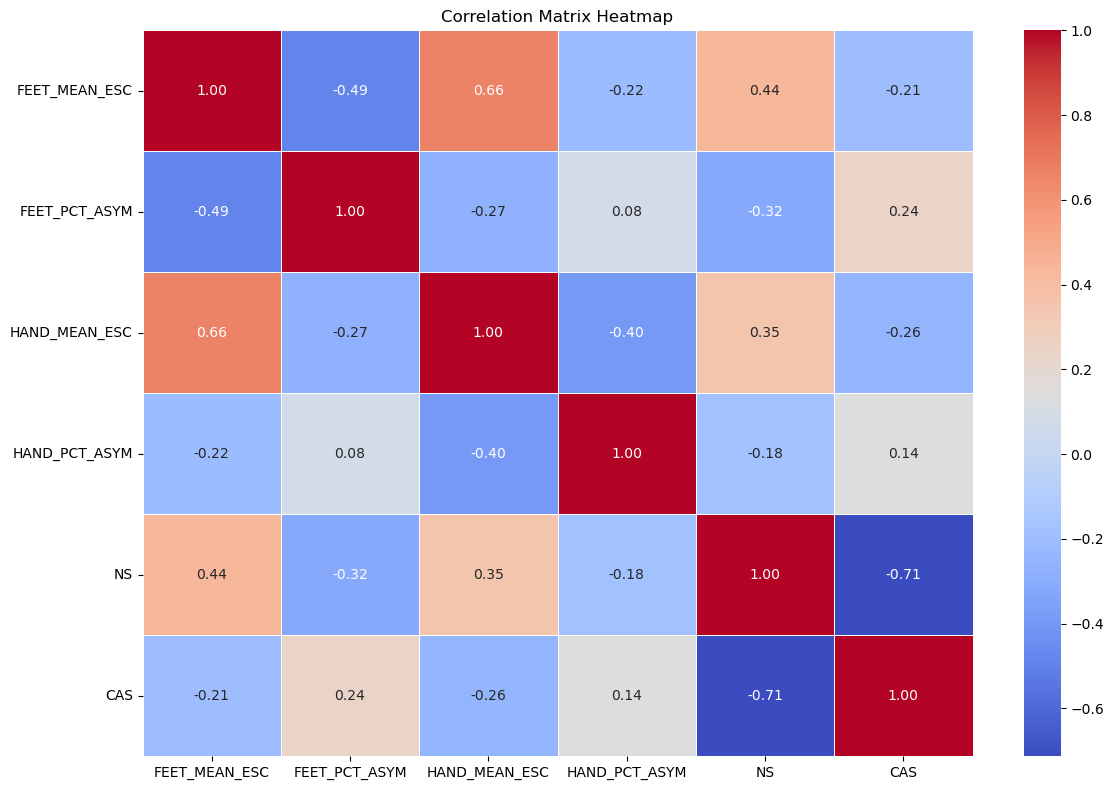

In [346]:
plot_heatmap(df[D.sudo_cols].corr(), figsize=(12, 8))

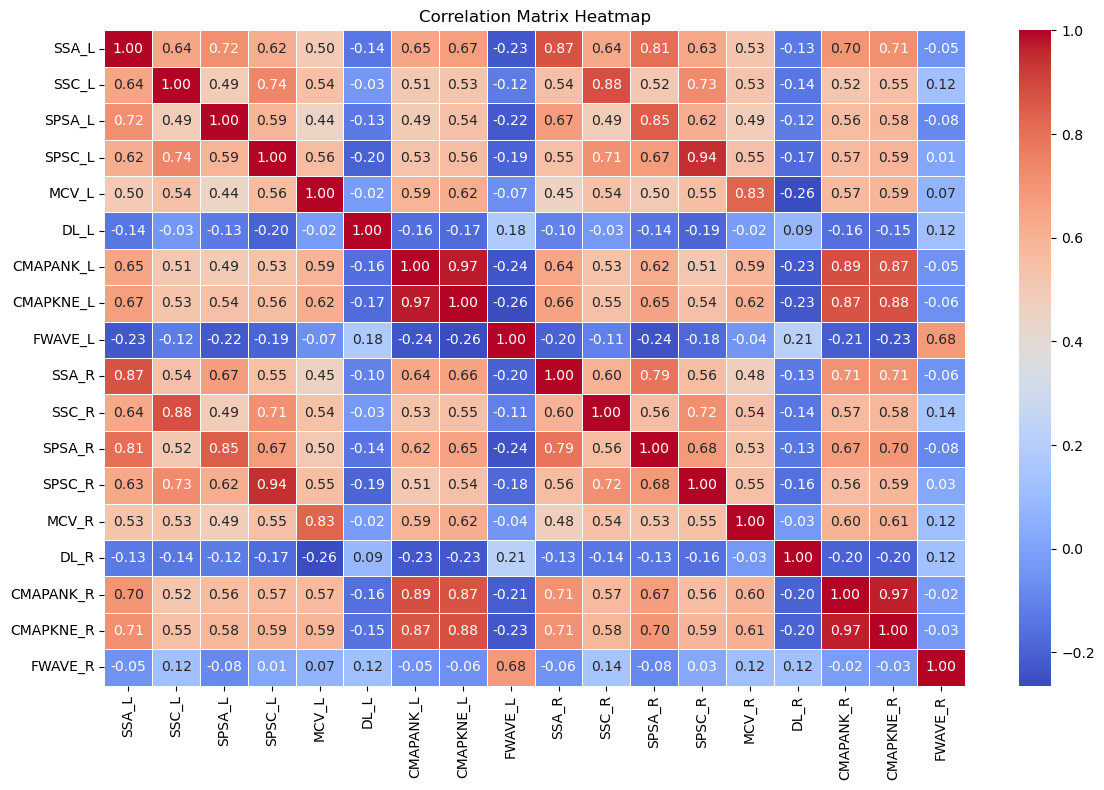

In [ ]:
plot_heatmap(df[D.ncs_cols].corr(), figsize=(12, 8))

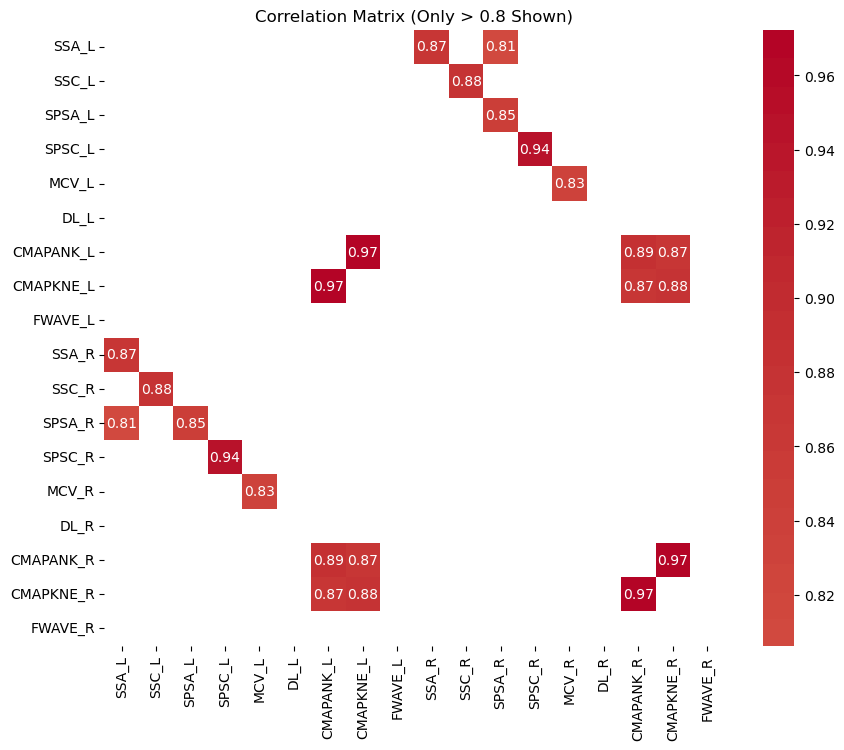

In [356]:
plot_heatmap_thresholded(df[D.ncs_cols].corr(), threshold=0.8, figsize=(12, 8))

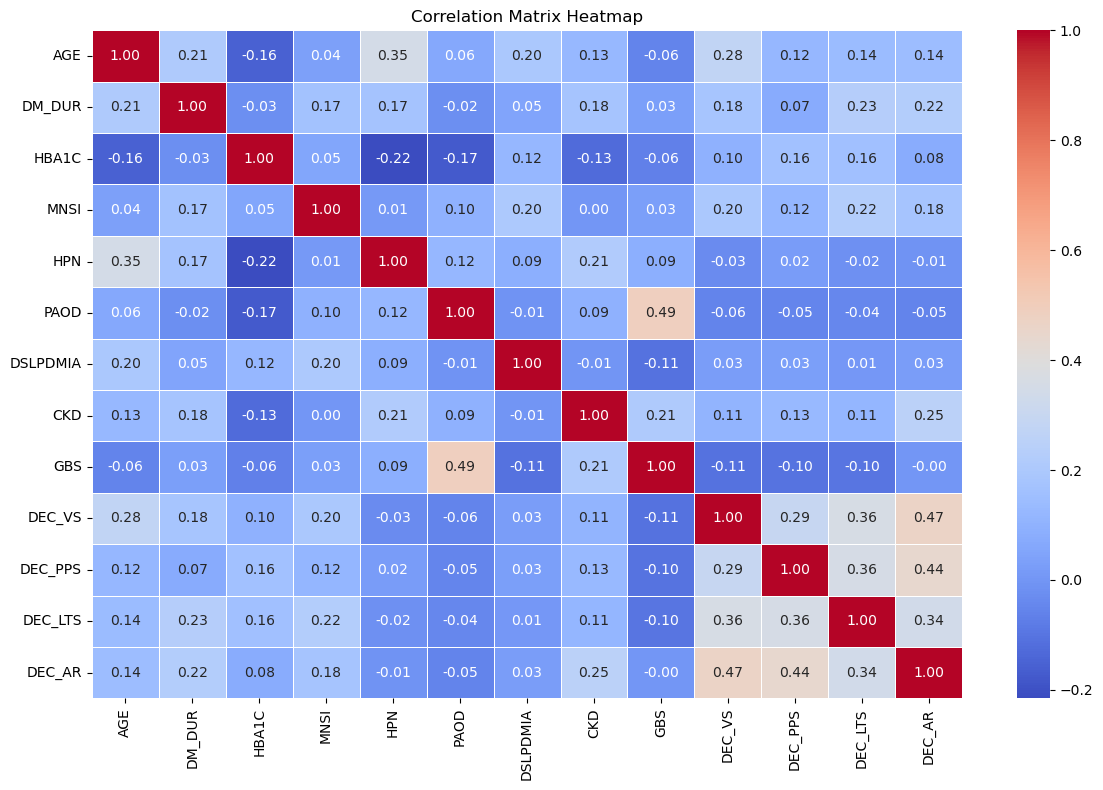

In [345]:
binary_cols = ["AGE", 'DM_DUR', 'HBA1C', 'MNSI'] + D.commorbidity_cols + D.neuro_cols
plot_heatmap(df[binary_cols].corr(), figsize=(12, 8))

In [332]:
X.columns

Index(['DEC_AR_Y', 'FEET_MEAN_ESC', 'FWAVE_R', 'SSA_L', 'FWAVE_L', 'SSA_R',
       'NS', 'SPSC_R', 'CMAPANK_L', 'MCV_R', 'INSULIN_Y', 'DSLPDMIA_Y',
       'HBA1C', 'HPN_Y', 'DL_L', 'SPSA_R', 'HAND_MEAN_ESC', 'CMAPKNE_R',
       'SSC_L', 'SEX_M', 'SPSC_L', 'CAS', 'DEC_VS_Y', 'DL_R', 'GBS_Y',
       'SPSA_L', 'HAND_PCT_ASYM', 'MNSI', 'MCV_L', 'SSC_R', 'PAOD_Y',
       'DEC_LTS_Y', 'DEC_PPS_Y', 'AGE', 'DM_DUR', 'CMAPANK_R', 'CMAPKNE_L',
       'SUBJ_Y', 'FEET_PCT_ASYM', 'CKD_Y'],
      dtype='object')